Link: https://www.youtube.com/watch?v=cdwGyCLn770&t=4705s
Stochastic Model Concept: https://www.investopedia.com/terms/s/stochastic-modeling.asp

Concepts

1. Randomness: Inputs include historical or theoretical variations, rather than constant values.
2. Time Element: These models typically track how variables evolve dynamically over time.
3. Probabilistic Outcomes: Instead of asking "what will happen?", a stochastic model asks "what are the probabilities of different things happening?"

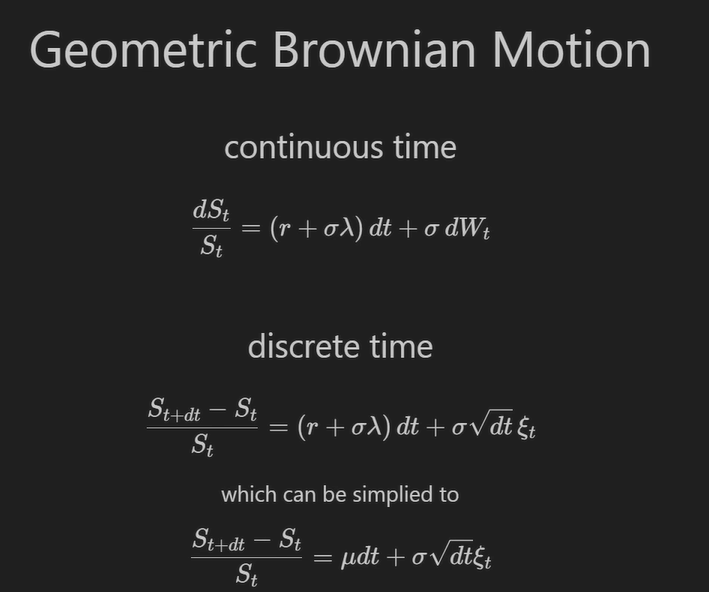

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Geometric Brownian Motion (10 years, 120 steps)
def gbm(n_years = 10, n_scenarios = 50, mu = 0.07, sigma = 0.15, steps_per_year = 12, s_0 = 100 ):
  dt = 1 / steps_per_year
  num_steps = n_years * steps_per_year
  xi = np.random.normal(size = (num_steps, n_scenarios)) # Volatility and it is random and normal
  result = ((1+mu)**dt) - 1 + sigma*np.sqrt(dt)*xi
  ans = pd.DataFrame(result)
  return s_0*(1+ans).cumprod()


In [ ]:
# More efficient

def gbm(n_years = 10, n_scenarios = 50, mu = 0.07, sigma = 0.15, steps_per_year = 12, s_0 = 100 ):
  dt = 1 / steps_per_year
  num_steps = n_years * steps_per_year
  rets_plus_1 = np.random.normal(loc = ((1+mu)**dt), scale = sigma*np.sqrt(dt), size = (num_steps, n_scenarios))
  return s_0*pd.DataFrame(rets_plus_1).cumprod()

<Axes: >

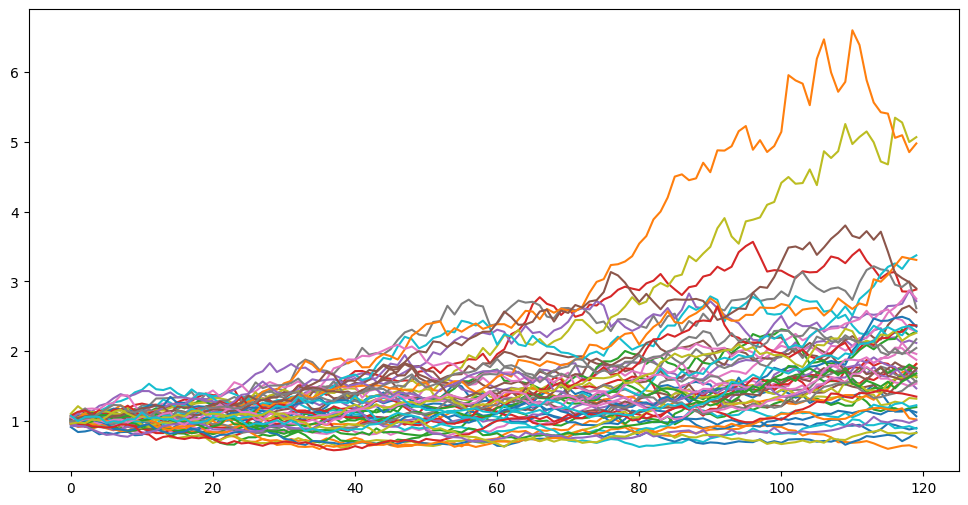

In [ ]:
gbm().plot(legend = False, figsize=(12, 6))

<Axes: >

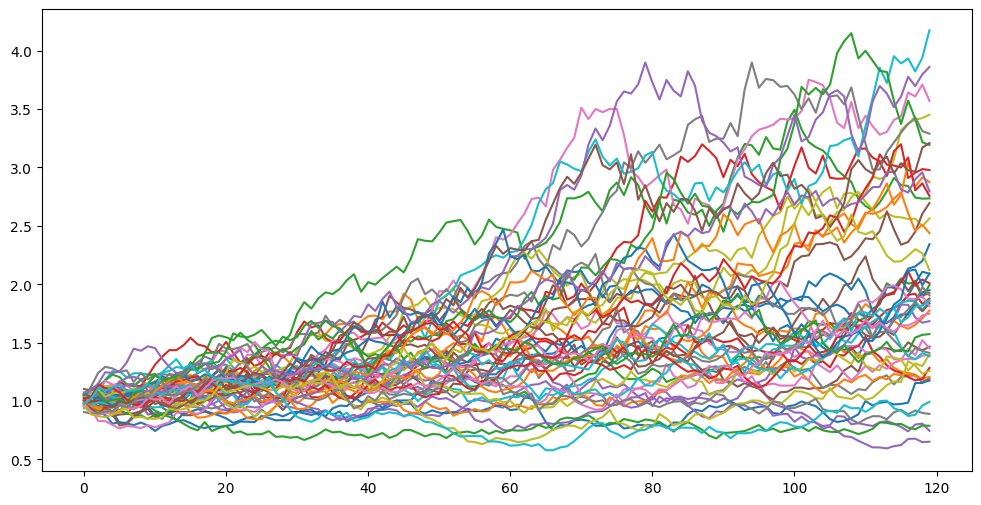

In [ ]:
ans = gbm()

# calculate wealth index
wealth_idx = (1+ans).cumprod()
wealth_idx.plot(legend = False, figsize=(12, 6))

In [10]:
def gbm_prepend(n_years = 10, n_scenarios = 50, mu = 0.07, sigma = 0.15, steps_per_year = 12, s_0 = 100 ):
  dt = 1 / steps_per_year
  num_steps = n_years * steps_per_year
  rets_plus_1 = np.random.normal(loc = ((1+mu)**dt), scale = sigma*np.sqrt(dt), size = (num_steps, n_scenarios))
  rets_plus_1 = pd.concat([pd.DataFrame(np.ones((1, n_scenarios))), pd.DataFrame(rets_plus_1)], ignore_index= True)
  return s_0*rets_plus_1.cumprod()

<Axes: >

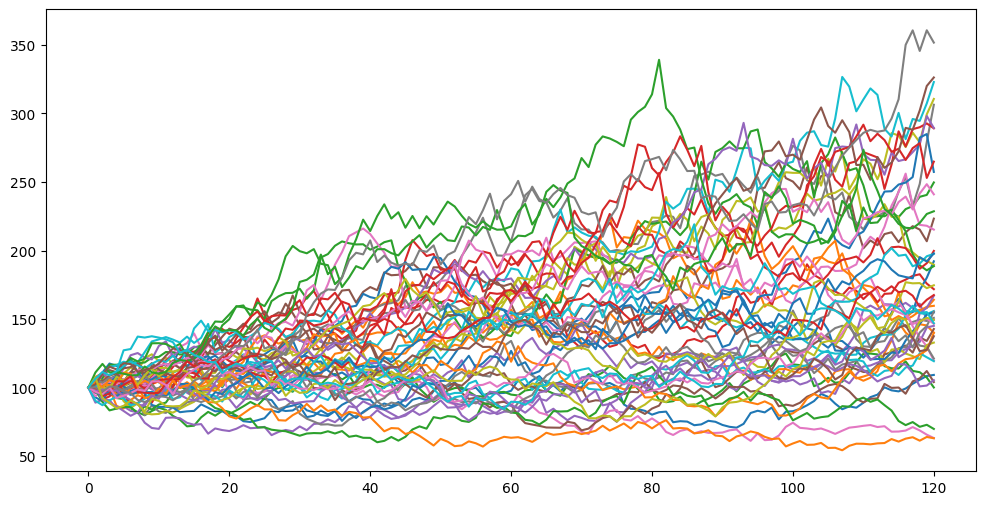

In [11]:
def gbm_prepend(n_years = 10, n_scenarios = 50, mu = 0.07, sigma = 0.15, steps_per_year = 12, s_0 = 100 ):
  dt = 1 / steps_per_year
  num_steps = n_years * steps_per_year
  rets_plus_1 = np.random.normal(loc = ((1+mu)**dt), scale = sigma*np.sqrt(dt), size = (num_steps, n_scenarios))
  rets_plus_1 = pd.concat([pd.DataFrame(np.ones((1, n_scenarios))), pd.DataFrame(rets_plus_1)], ignore_index= True)
  return s_0*rets_plus_1.cumprod()

gbm_prepend().plot(legend = False, figsize=(12, 6))

Interactive Plotting

In [5]:
import ipywidgets as widgets

In [ ]:
def interactive_gbm(n_years = 10, n_scenarios = 100, mu = 0.07, sigma = 0.15, s_0 = 100):
  prices = gbm_prepend(n_years = n_years, n_scenarios = n_scenarios, mu = mu, sigma = sigma, s_0 = s_0)
  ax = prices.plot(legend = False, figsize = (12, 6))
  ax.axhline( y = s_0, ls = '--', color = 'black')

In [ ]:
widgets.interactive(interactive_gbm, n_years = (1, 30), n_scenarios = (1, 1000), mu = (-0.1, 0.1), sigma = (0, 0.3), s_0 = (100, 1000) )

interactive(children=(IntSlider(value=10, description='n_years', max=30, min=1), IntSlider(value=100, descript…

In [13]:
def interactive_gbm(n_years=10, n_scenarios=100, mu=0.07, sigma=0.15, s_0=100):
    prices = gbm_prepend(n_years=n_years, n_scenarios=n_scenarios, mu=mu, sigma=sigma, s_0=s_0)
    terminal_wealth = prices.iloc[-1]

    fig, (wealth_ax, hist_ax) = plt.subplots(nrows=1, ncols=2, sharey=True, gridspec_kw={'width_ratios':[2,1]}, figsize=(24, 10))
    plt.subplots_adjust(wspace=0)

    prices.plot(ax=wealth_ax, legend=False, color='skyblue')
    wealth_ax.axhline(y=s_0, ls="--", color='black')
    wealth_ax.set_title('Simulated Asset Price Paths')
    wealth_ax.set_xlabel('Time Steps (Months)')
    wealth_ax.set_ylabel('Asset Price')

    terminal_wealth.plot.hist(ax=hist_ax, bins=50, ec='white', color='skyblue', orientation='horizontal')
    hist_ax.set_title('Terminal Wealth Distribution')
    hist_ax.set_xlabel('Frequency')
    hist_ax.set_ylabel('Terminal Asset Price') # This label will align with the shared y-axis

In [14]:
widgets.interactive(interactive_gbm, n_years=(1, 30), n_scenarios=(1, 1000), mu=(-0.1, .1, 0.01), sigma=(0, 0.3, 0.01), s_0=(100, 1000, 100))

interactive(children=(IntSlider(value=10, description='n_years', max=30, min=1), IntSlider(value=100, descript…

The generated graph visualizes asset price simulations using the Geometric Brownian Motion (GBM) model, a fundamental stochastic process in financial modeling. It comprises two main components:

Simulated Asset Price Paths (Left Plot): This section displays multiple distinct trajectories representing various potential price evolutions of an asset over a specified number of years (e.g., 1 to 30 years). Each line illustrates a unique scenario, starting from an initial price. This plot effectively conveys the inherent randomness and potential divergence of asset prices due to factors like mean return (drift) and volatility. It highlights the wide range of outcomes possible over time, emphasizing the uncertain nature of future asset performance.

Terminal Wealth Distribution (Right Plot): This horizontal histogram presents the distribution of the asset's price at the end of the simulation period (terminal wealth) across all simulated scenarios. It provides crucial insights into the probability of achieving different final values. For instance, one can observe the most probable range of terminal wealth, the overall spread (indicating risk), and the likelihood of extreme gains or losses. This distribution is vital for understanding the risk-reward profile associated with the asset under the specified parameters.